# Figure 1

### Load Difficulty Result

In [1]:
diff_idx = input("INPUT 'visualization_target for difficulty RUN_ID'(e.g., 111110000): ")

print(f'Figure will be drawn based on the run_id_{diff_idx} dataset')

Figure will be drawn based on the run_id_111110000 dataset


In [2]:
complexity_idx = input("INPUT 'visualization_target for complexity RUN_ID'(e.g., 20000): ")

print(f'Figure will be drawn based on the run_id_{complexity_idx} dataset')

Figure will be drawn based on the run_id_20000 dataset


In [4]:
import pandas as pd
import numpy as np
from datetime import datetime
import os
from glob import glob


from lib.annotation.tools.Result_Prep import Result_Prep as Result_Prep_D
from lib.code_complexity.tools.Result_Prep import Result_Prep as Result_Prep_C

import lib.stats.chowtest as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from matplotlib import pyplot as plt
import matplotlib as mpl
from lib.visualization.plot_generator import PlotGen
import lib.visualization.figure_setting as figure_setting
from matplotlib.lines import Line2D

mpl.rcParams.update(figure_setting.fig_setting)
# mpl.rcParams['font.family'] = figure_setting.init_font()



In [5]:
rp_prep_diff = Result_Prep_D(diff_idx)
diff_df = rp_prep_diff.data_prep()

In [6]:
diff_df

,rel_week,o_result,r_cnt,tot_cnt,rate
0,-109.0,0,24,57,42.105263
1,-109.0,1,28,57,49.122807
2,-109.0,2,5,57,8.771930
3,-108.0,0,47,137,34.306569
4,-108.0,1,73,137,53.284672
...,...,...,...,...,...
792,155.0,0,9,87,10.344828
793,155.0,1,38,87,43.678161
795,156.0,0,6,57,10.526316
797,156.0,2,31,57,54.385965


In [7]:
rp_prep_comp = Result_Prep_C(complexity_idx)
comp_df = rp_prep_comp.data_prep()

100%|██████████| 65/65 [00:12<00:00,  5.15it/s]


In [17]:
def draw_complexity_regression(ax, x, y, st_chow,
                               F_stat_1, p_value_1, title,
                               panel_label=''):

    split_idx = np.where(x < 0)[0][-1] + 1
    x1 = x[:split_idx]
    x2 = x[split_idx:]

    # ── scatter plot 
    plot_gen = PlotGen()
    plot_gen.draw_scatter_plot(ax, x, y)

    
    # ── Before ChatGPT
    plot_gen.fill_confidence_interval(ax, x1, st_chow.y1_predict - st_chow.y1_conf_interval, st_chow.y1_predict + st_chow.y1_conf_interval
                                          , label=None, color = figure_setting.PALETTE['primary'])
    plot_gen.draw_line_plot(ax, x1, st_chow.y1_predict, label='Before Gen AI', color=figure_setting.PALETTE['primary'])

    # ── After ChatGPT
    plot_gen.fill_confidence_interval(ax, x2, st_chow.y2_predict - st_chow.y2_conf_interval, st_chow.y2_predict + st_chow.y2_conf_interval
                                          , label=None, color = figure_setting.PALETTE['accent'])
    plot_gen.draw_line_plot(ax, x2, st_chow.y2_predict,
            label='After Gen AI',
            color=figure_setting.PALETTE['accent'])

    
    # ── Overall fit 
    plot_gen.draw_line_plot(ax, x, st_chow.y_predict, label='Overall fit', color=figure_setting.PALETTE['neutral'], opt='overall')

    # ── virtical line for chatGPT release
    plot_gen.draw_vertical_line(ax, x=0, label=None)


    # ── set title with p-value
    plot_gen.set_title_two_lines(ax, prefix=None, title_text=title, p_value=p_value_1, gap=0.04)

    # ── spines
    plot_gen.set_spines(ax)
    plot_gen.set_xticks(ax, np.arange(-104, 158, 52))

    # ── set x lim
    plot_gen.set_lims(ax, x, y)

Basic 49.66170814130287
Intermediate 68.06697168977946
Advanced 224.3258437750739
4.144527980372589


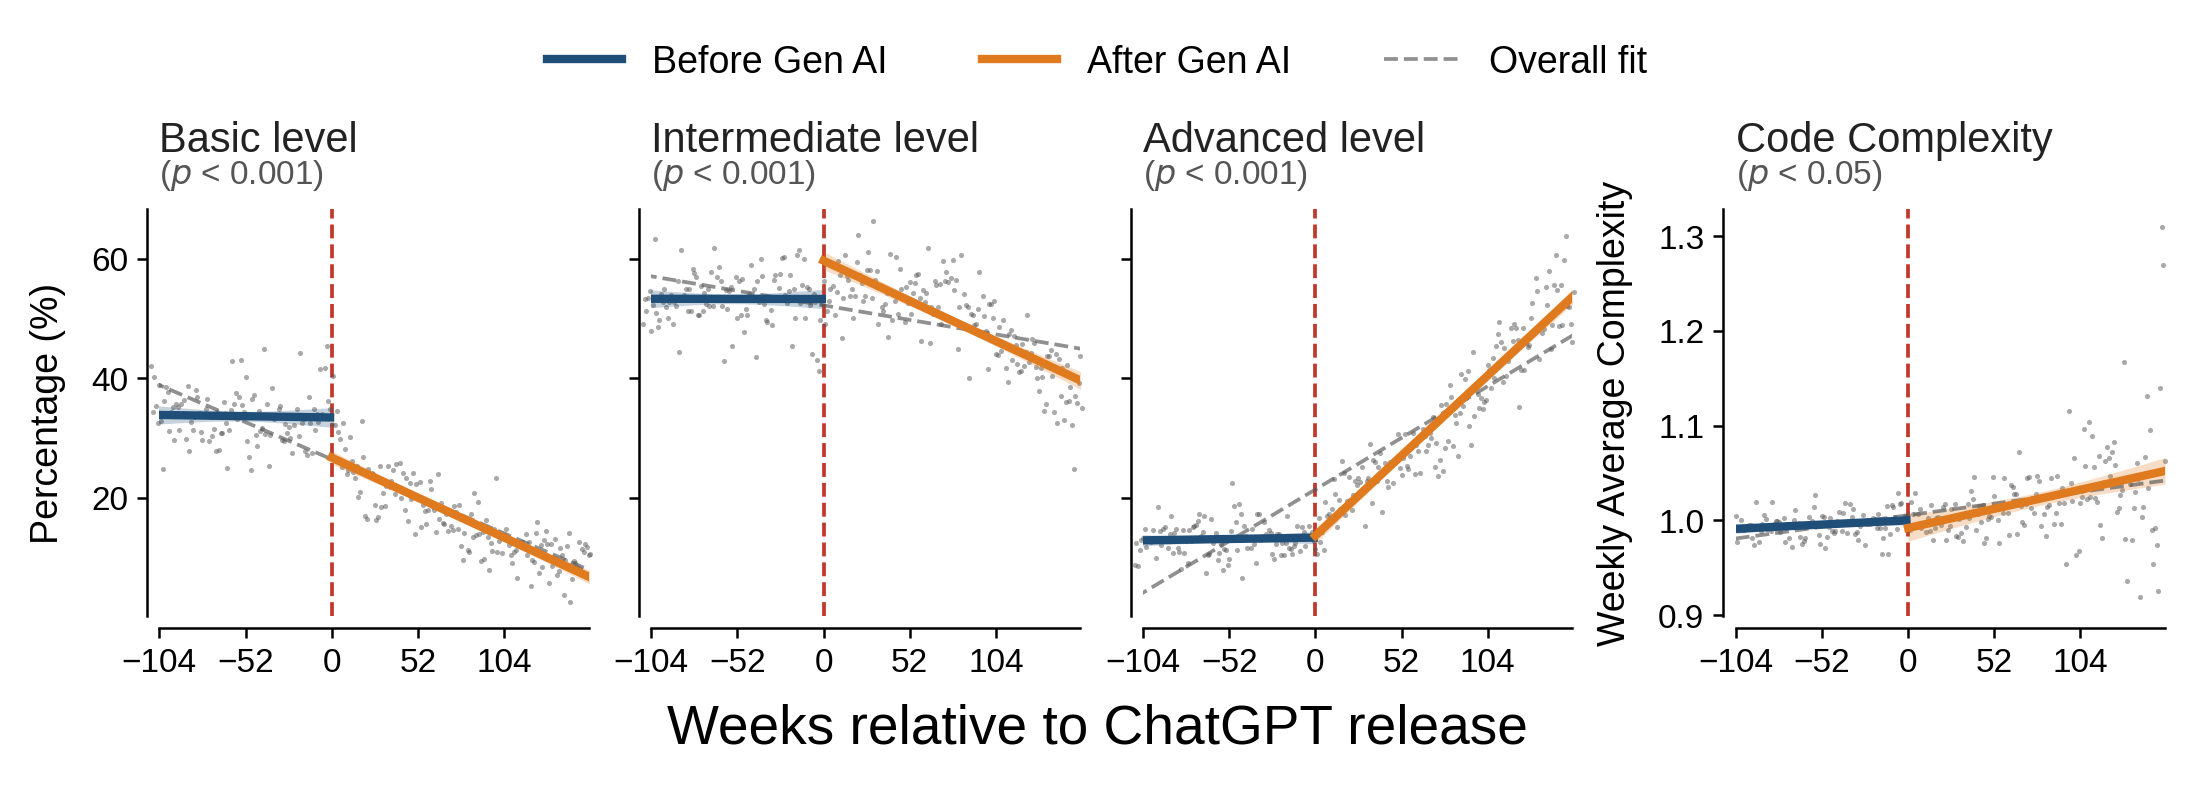

In [18]:
fig, axes = plt.subplots(1, 4,
                        figsize=(7.2, 2.2),
                        constrained_layout=True,
                        dpi=300,
                        sharex=True
                    )
# draw question's difficulty related panels
label_dict = {'A': 'Basic', 'B': 'Intermediate', 'C': 'Advanced'}

for i, (label, title) in enumerate(label_dict.items()):
    chk_cnt = diff_df[diff_df['o_result'] == str(i)].sort_values(
        by=['rel_week'], ascending=True).reset_index(drop=True)
    x = chk_cnt['rel_week'].values
    y = chk_cnt['rate'].values

    st_chow = st.ChowTest(x, y, 0.95, np.where(x < 0)[0][-1] + 1)
    F_stat, p_value = st_chow.chow_test()
    draw_complexity_regression(
        axes[i], x, y, st_chow, F_stat, p_value,
        title=f"{title} level", panel_label=""
    )
    print(title, F_stat)

y_min = min(ax.get_ylim()[0] for ax in axes[:3])
y_max = max(ax.get_ylim()[1] for ax in axes[:3])
for ax in axes[:3]:
    ax.set_ylim(y_min, y_max)


for ax in axes[1:3]:
    ax.tick_params(labelleft=False)

# draw complexity related panels
chk_cnt = comp_df.sort_values(by=['rel_week'], ascending=True).reset_index(drop=True)
x = chk_cnt['rel_week'].values
y = chk_cnt['cyclomatic_complexity'].values

st_chow = st.ChowTest(x, y, 0.95, np.where(x < 0)[0][-1] + 1)
F_stat, p_value = st_chow.chow_test()
draw_complexity_regression(
    axes[-1], x, y, st_chow, F_stat, p_value,
    title="Code Complexity", panel_label=""
)
print(F_stat)

axes[-1].set_ylabel("Weekly Average Complexity", labelpad=6)

fig.supxlabel("Weeks relative to ChatGPT release")

axes[0].set_ylabel("Percentage (%)", labelpad=6)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.99),
    ncol=3, frameon=False,
    handlelength=2.0, columnspacing=2.5
)
plt.savefig('./fig/Fig1.pdf', bbox_inches='tight', dpi=300)

Basic 49.66170814130287
Intermediate 68.06697168977946
Advanced 224.3258437750739
4.144527980372589


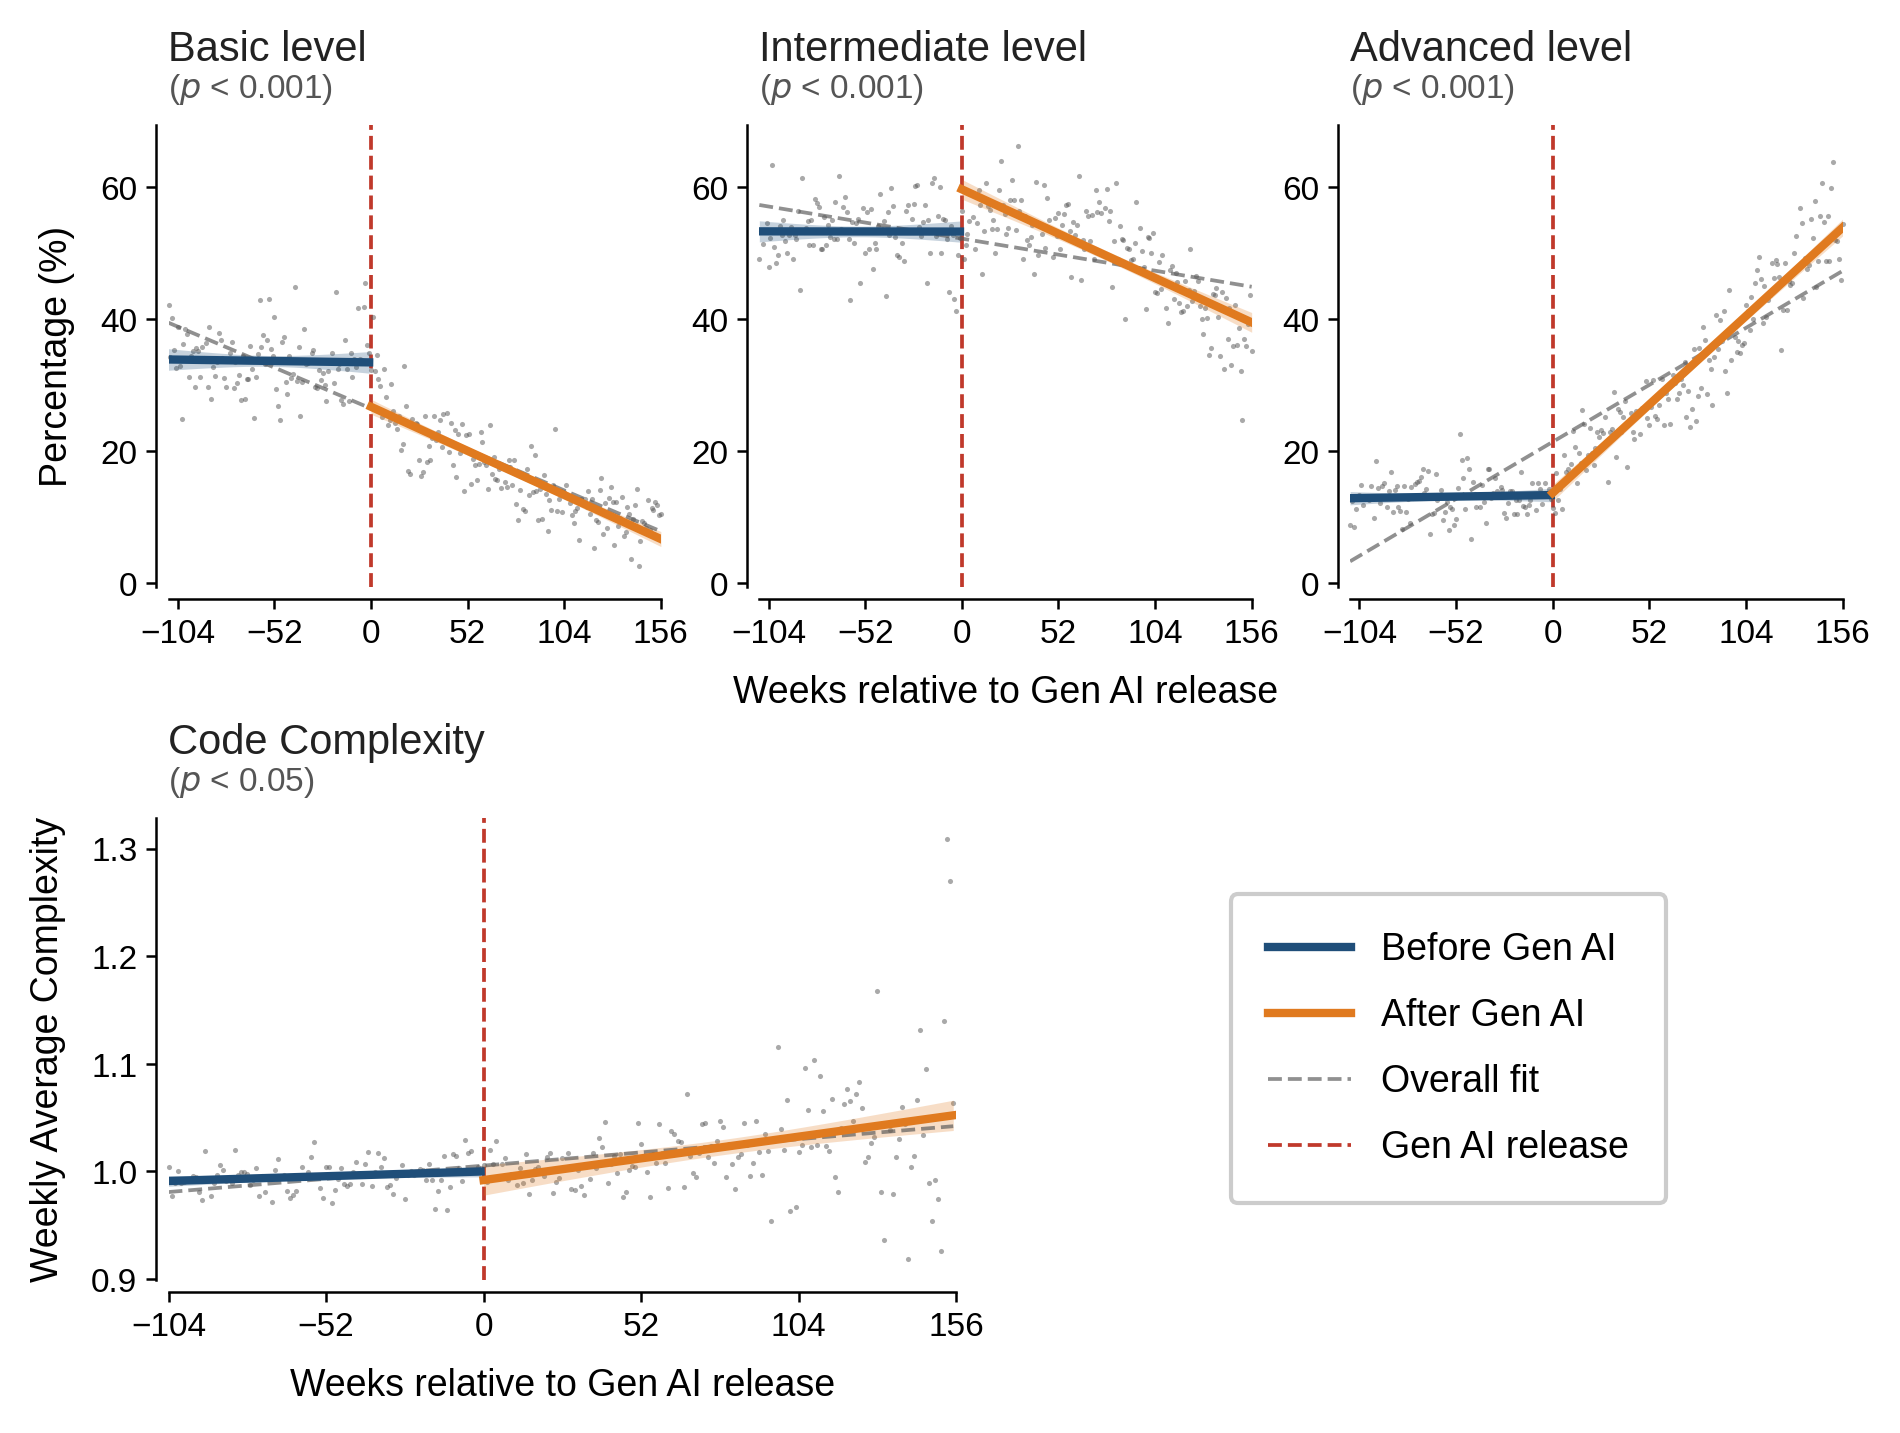

In [20]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(7.2, 5.0), dpi=300)
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.5, wspace=0.5)

# a: 3패널 (각 2칸씩)
ax_a = fig.add_subplot(gs[0, 0:2])
ax_b = fig.add_subplot(gs[0, 2:4], sharey=ax_a)
ax_c = fig.add_subplot(gs[0, 4:6], sharey=ax_a)

# b: 가운데 (2~4칸)
ax_d = fig.add_subplot(gs[1, 0:3])

axes = [ax_a, ax_b, ax_c, ax_d]

for i, (label, title) in enumerate(label_dict.items()):
    chk_cnt = diff_df[diff_df['o_result'] == str(i)].sort_values(
        by=['rel_week'], ascending=True).reset_index(drop=True)
    x = chk_cnt['rel_week'].values
    y = chk_cnt['rate'].values

    st_chow = st.ChowTest(x, y, 0.95, np.where(x < 0)[0][-1] + 1)
    F_stat, p_value = st_chow.chow_test()
    draw_complexity_regression(
        axes[i], x, y, st_chow, F_stat, p_value,
        title=f"{title} level", panel_label=""
    )
    print(title, F_stat)

y_min = min(ax.get_ylim()[0] for ax in axes[:3])
y_max = max(ax.get_ylim()[1] for ax in axes[:3])
for ax in axes[:3]:
    ax.set_ylim(y_min, y_max)
    




# draw complexity related panels
chk_cnt = comp_df.sort_values(by=['rel_week'], ascending=True).reset_index(drop=True)
x = chk_cnt['rel_week'].values
y = chk_cnt['cyclomatic_complexity'].values

st_chow = st.ChowTest(x, y, 0.95, np.where(x < 0)[0][-1] + 1)
F_stat, p_value = st_chow.chow_test()
draw_complexity_regression(
    ax_d, x, y, st_chow, F_stat, p_value,
    title="Code Complexity", panel_label=""
)
print(F_stat)
ax_d.set_xticks(np.arange(-104, 158, 52))
ax_d.set_ylabel("Weekly Average Complexity", labelpad=6)
ax_d.set_xlabel("Weeks relative to Gen AI release", labelpad=6)
ax_b.set_xlabel("Weeks relative to Gen AI release", labelpad=6)

# fig.supxlabel("Weeks relative to ChatGPT release")

ax_a.set_ylabel("Percentage (%)", labelpad=6)
ax_legend = fig.add_subplot(gs[1, 4:5])
ax_legend.axis('off')
handles, labels = ax_a.get_legend_handles_labels()

extra = Line2D([0], [0], color='#C0392B', ls='--', lw=0.9,
               label='Gen AI release')
handles.append(extra)
labels.append('Gen AI release')

ax_legend.legend(
    handles, labels,
    loc='center',
    frameon=True,           # 박스 켜기
    edgecolor='#cccccc',    # 박스 테두리 연회색
    framealpha=1.0,
    fontsize=9,
    handlelength=2.2,       # 선 샘플 길이
    borderpad=1.0,          # 박스 안쪽 여백
    labelspacing=0.8,       # 항목 간격
)

plt.savefig('./fig/Fig1.pdf', bbox_inches='tight', dpi=300)

In [14]:
np.arange(-104, 157, 52)

array([-104,  -52,    0,   52,  104,  156])